# Heart Disease Prediction — Voting Ensemble Classifier

Combines Logistic Regression, Decision Tree, and SVM via soft voting to leverage diverse decision boundaries.

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

## 2. Load Data

In [2]:
df = pd.read_csv('heart.csv')
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


## 3. Train-Test Split & Scaling

In [3]:
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

## 4. Define Base Models

In [4]:
clf1 = LogisticRegression(max_iter=1000)
clf2 = DecisionTreeClassifier(random_state=42)
clf3 = SVC(probability=True, random_state=42)

models = {'Logistic Regression': clf1, 'Decision Tree': clf2, 'SVM': clf3}

for name, model in models.items():
    model.fit(X_train_s, y_train)
    acc = accuracy_score(y_test, model.predict(X_test_s))
    print(f'{name}: {acc:.4f}')

Logistic Regression: 0.8033
Decision Tree: 0.7049
SVM: 0.8197


## 5. Build Voting Ensemble

In [5]:
voting = VotingClassifier(
    estimators=[('lr', clf1), ('dt', clf2), ('svc', clf3)],
    voting='soft'
)
voting.fit(X_train_s, y_train)
y_pred = voting.predict(X_test_s)

## 6. Evaluation

In [6]:
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f'Accuracy:  {acc:.4f}')
print(f'Precision: {prec:.4f}')
print(f'Recall:    {rec:.4f}')
print(f'F1-Score:  {f1:.4f}')

Accuracy:  0.8033
Precision: 0.7838
Recall:    0.8788
F1-Score:  0.8286


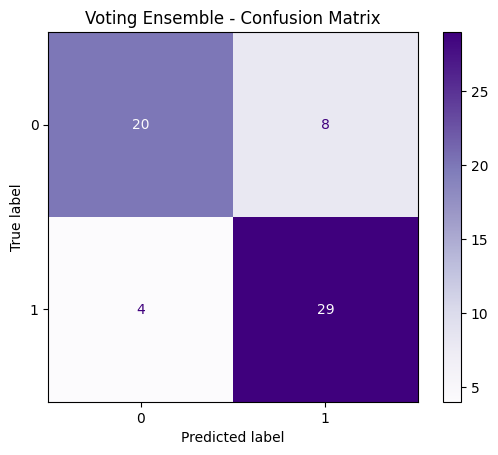

In [7]:
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot(cmap='Purples')
plt.title('Voting Ensemble - Confusion Matrix')
plt.show()

## 7. Individual vs Ensemble Comparison

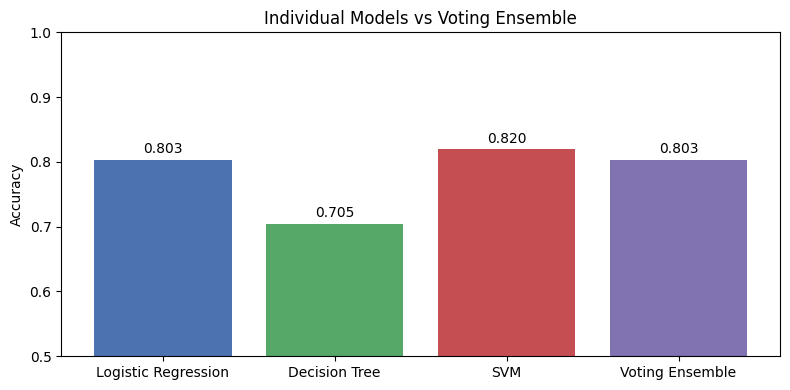

In [8]:
results = {}
for name, model in models.items():
    results[name] = accuracy_score(y_test, model.predict(X_test_s))
results['Voting Ensemble'] = acc

plt.figure(figsize=(8, 4))
plt.bar(results.keys(), results.values(), color=['#4C72B0', '#55A868', '#C44E52', '#8172B2'])
plt.ylabel('Accuracy')
plt.title('Individual Models vs Voting Ensemble')
plt.ylim(0.5, 1.0)
for i, (k, v) in enumerate(results.items()):
    plt.text(i, v + 0.01, f'{v:.3f}', ha='center')
plt.tight_layout()
plt.show()